# Elaborato — Apprendimento Automatico e Apprendimento Profondo

**Studente:** Daniele Di Vito — **Matricola:** 0322500152

**Dataset scelto:** [Shell Commands Used by Participants of Hands-on Cybersecurity Training](https://archive.ics.uci.edu/dataset/869/shell+commands+used+by+participants+of+hands-on+cybersecurity+training) (UCI Machine Learning Repository, id 869)

Il dataset raccoglie **21.459 comandi shell** (Bash, ZSH e Metasploit) digitati da **275 partecipanti** a esercitazioni pratiche di cybersecurity svolte sulla piattaforma KYPO Cyber Range dell'Università Masaryk. Ogni record JSON contiene il comando con i suoi argomenti e alcuni metadati (timestamp, working directory, host, tipo di shell).

**Obiettivo dell'esperimento:** riconoscere **lo scenario di training** (7 classi: *Locust 3302*, *Junior hacker adaptive*, *Junior hacker*, *House of cards*, *Secret laboratory*, *Webmin exploit practice*, *SQL injection*) a cui appartiene un comando osservato, usando il comando stesso e il suo contesto recente nella sessione. È un problema di classificazione multi-classe su dati testuali con rilevanza pratica nella *security analytics*: identificare automaticamente a quale attività appartiene ciò che un utente sta digitando in un log di shell.

**Task svolti nel notebook:**
1. Analisi delle feature mediante PCA e visualizzazione dei risultati;
2. Implementazione di tre algoritmi di classificazione (Logistic Regression, Random Forest, SVM lineare);
3. Calcolo delle metriche di valutazione: Accuracy, Precision, Recall, F-measure, ROC AUC;
4. Visualizzazione della matrice di confusione e della curva ROC AUC per ogni classificatore;
5. **Opzione (b):** approccio di spiegabilità con **SHAP**.

## 0. Import delle librerie e configurazione

In [1]:
import os
import re
import json
import glob
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import label_binarize
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc)

import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# cartella in cui vengono salvate le immagini prodotte dal notebook
IMG_DIR = 'img'
os.makedirs(IMG_DIR, exist_ok=True)

## 1. Caricamento del dataset

Il dataset è distribuito come archivio `data.zip` (record Zenodo [10.5281/zenodo.8136017](https://doi.org/10.5281/zenodo.8136017), linkato dalla pagina UCI). L'archivio contiene una cartella per ciascuno dei 7 scenari di training; ogni cartella contiene file in formato **JSON Lines** (uno per ogni *sessione*, cioè per ogni sandbox assegnata a un partecipante), con un record per ogni comando digitato.

Per rendere il notebook riproducibile: se il file consolidato `shell_commands.csv` è già presente viene caricato direttamente, altrimenti l'archivio viene scaricato da Zenodo, estratto e convertito in un unico `DataFrame`. Oltre al testo del comando si conservano lo scenario (la classe da predire), l'identificativo della **sessione** e il timestamp, con cui i comandi vengono riordinati cronologicamente all'interno di ogni sessione.

In [2]:
CSV_PATH = 'shell_commands.csv'
DATA_URL = 'https://zenodo.org/api/records/8136017/files/data.zip/content'

if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
else:
    if not os.path.exists('data.zip'):
        urllib.request.urlretrieve(DATA_URL, 'data.zip')
    if not os.path.exists('data'):
        with zipfile.ZipFile('data.zip') as z:
            z.extractall('data')
    records = []
    for path in sorted(glob.glob('data/**/*.json', recursive=True)):
        rel = os.path.relpath(path, 'data')
        scenario = rel.split(os.sep)[0]
        with open(path, encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                rec = json.loads(line)
                records.append({
                    'scenario': scenario,
                    'session': rel,              # un file JSON = una sessione sandbox
                    'cmd': rec.get('cmd'),
                    'cmd_type': rec.get('cmd_type'),
                    'timestamp': rec.get('timestamp_str'),
                })
    df = pd.DataFrame(records)
    # si scartano i (pochissimi) record privi del testo del comando
    df = df.dropna(subset=['cmd'])
    # ordinamento cronologico dei comandi all'interno di ogni sessione
    df = df.sort_values(['session', 'timestamp']).reset_index(drop=True)
    df.to_csv(CSV_PATH, index=False)

print(f'Numero di comandi: {len(df)}   |   Numero di sessioni: {df.session.nunique()}')
df.head()

Numero di comandi: 21089   |   Numero di sessioni: 267


,scenario,session,cmd,cmd_type,timestamp
0,House of cards,House of cards/2019-08-15 KYPO Summer School/s...,nmap 172.18.1.5,bash-command,2019-08-14T15:40:19.345589Z
1,House of cards,House of cards/2019-08-15 KYPO Summer School/s...,nmap -A -p 22 172.18.1.5,bash-command,2019-08-14T15:40:34.470540Z
2,House of cards,House of cards/2019-08-15 KYPO Summer School/s...,service postgresql start,bash-command,2019-08-14T15:46:27.404601Z
3,House of cards,House of cards/2019-08-15 KYPO Summer School/s...,msfdb init,bash-command,2019-08-14T15:46:31.391699Z
4,House of cards,House of cards/2019-08-15 KYPO Summer School/s...,msfconsole,bash-command,2019-08-14T15:46:34.560332Z


### 1.1 Analisi esplorativa

Prima di costruire le feature osserviamo la distribuzione delle classi. Il dataset è **sbilanciato**: lo scenario più numeroso (*Locust 3302*) contiene oltre 11.000 comandi e 134 sessioni, quello più raro (*SQL injection*) meno di 200 comandi e 8 sessioni. Di questo si terrà conto usando uno split **stratificato** e metriche **macro** (media non pesata sulle classi).

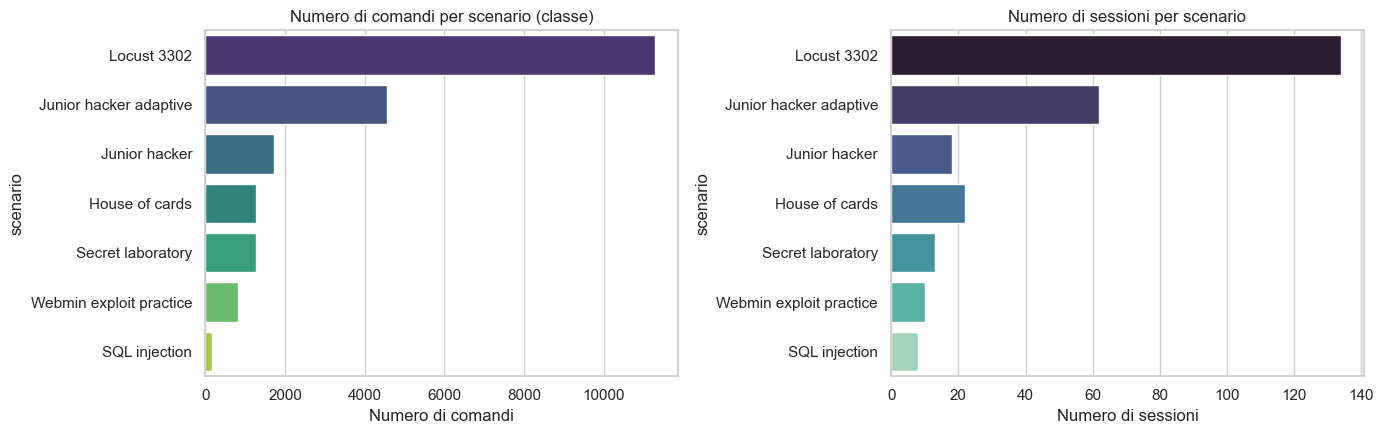

Esempi di comandi:
  [House of cards] 'nmap 172.18.1.5'
  [Junior hacker adaptive] 'echo Adam'
  [Junior hacker] 'ls'
  [Locust 3302] 'nmap --help'
  [SQL injection] 'root'
  [Secret laboratory] 'nmap 10.1.26.9'
  [Webmin exploit practice] 'Nmap'


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ordine = df['scenario'].value_counts()
sns.barplot(x=ordine.values, y=ordine.index, hue=ordine.index,
            palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Numero di comandi per scenario (classe)')
axes[0].set_xlabel('Numero di comandi')

sess_per_classe = df.groupby('scenario')['session'].nunique().loc[ordine.index]
sns.barplot(x=sess_per_classe.values, y=sess_per_classe.index, hue=sess_per_classe.index,
            palette='mako', legend=False, ax=axes[1])
axes[1].set_title('Numero di sessioni per scenario')
axes[1].set_xlabel('Numero di sessioni')

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/distribuzione_classi.png', bbox_inches='tight')
plt.show()

print('Esempi di comandi:')
for s in df['scenario'].unique():
    print(f'  [{s}] {df[df.scenario == s]["cmd"].iloc[0]!r}')

### 1.2 Quanto è ambiguo un comando isolato?

Molti comandi (`ls`, `cd ..`, `exit`, ...) sono usati in **tutti** gli scenari: un classificatore che osserva il singolo comando non può fare meglio che assegnare a ogni comando ripetuto la sua classe più frequente. La cella seguente quantifica questo **tetto teorico**.

In [4]:
IP_RE = re.compile(r'\b\d{1,3}(?:\.\d{1,3}){3}\b')

def pulisci_comando(cmd):
    """Minuscole + anonimizzazione degli indirizzi IP (specifici della rete di ogni scenario)."""
    return IP_RE.sub(' IPADDR ', str(cmd).lower())

df['cmd_clean'] = df['cmd'].apply(pulisci_comando)

per_comando = df.groupby('cmd_clean')['scenario']
tetto = per_comando.apply(lambda s: s.value_counts().iloc[0]).sum() / len(df)
ambigui = per_comando.nunique()
print(f'Comandi distinti: {len(ambigui)}, di cui presenti in piu di uno scenario: {(ambigui > 1).sum()}')
print(f'Tetto teorico di accuracy classificando il singolo comando: {tetto:.3f}')
print('\nComandi ambigui piu frequenti:')
print(df[df.cmd_clean.isin(ambigui[ambigui > 1].index)]['cmd_clean'].value_counts().head(8))

Comandi distinti: 5819, di cui presenti in piu di uno scenario: 401
Tetto teorico di accuracy classificando il singolo comando: 0.796

Comandi ambigui piu frequenti:
cmd_clean
ls                    2173
cd ..                  522
exploit                445
run                    364
set lhost  IPADDR      336
show options           335
exit                   319
msfconsole             269
Name: count, dtype: int64


**Conseguenza progettuale.** Il singolo comando è spesso ambiguo (il solo `ls` costituisce circa il 10% del dataset). Poiché però i comandi arrivano in **sequenza** all'interno di una sessione, ogni esempio viene rappresentato con una **finestra di contesto**: il comando corrente concatenato ai 10 comandi precedenti della stessa sessione. Il contesto (gli strumenti usati poco prima, i bersagli, i passi dell'esercitazione) disambigua i comandi generici.

## 2. Preprocessing e costruzione delle feature

Scelte progettuali:
* **anonimizzazione**: gli indirizzi IP vengono sostituiti dal token generico `IPADDR`. Ogni scenario usa una rete emulata con indirizzi propri: senza questa pulizia il classificatore potrebbe "barare" riconoscendo l'indirizzo IP invece del contenuto del comando (*data leakage*);
* **finestra di contesto**: ogni esempio è la concatenazione del comando corrente e dei 10 precedenti della stessa sessione (per i primi comandi di una sessione la finestra è più corta);
* **TF-IDF** (Term Frequency – Inverse Document Frequency) con vocabolario limitato ai **1000 termini più frequenti** e tokenizzazione adattata alla sintassi shell (conserva trattini, slash e punti, significativi per flag e percorsi). La matrice risultante, convertita in formato denso, è adatta anche alla PCA.

In [5]:
K = 10  # numero di comandi precedenti inclusi nella finestra di contesto

documenti = []
for sessione, gruppo in df.groupby('session', sort=False):
    comandi = gruppo['cmd_clean'].tolist()
    documenti += [' '.join(comandi[max(0, i - K):i + 1]) for i in range(len(comandi))]
df['doc'] = documenti

vectorizer = TfidfVectorizer(max_features=1000,
                             token_pattern=r'[a-zA-Z][a-zA-Z\-_/\.]+')
X = vectorizer.fit_transform(df['doc']).astype(np.float32).toarray()
y = df['scenario'].values
feature_names = vectorizer.get_feature_names_out()
class_names = sorted(df['scenario'].unique())

print(f'Matrice delle feature: {X.shape[0]} campioni x {X.shape[1]} feature TF-IDF')
print('Esempio di documento (comando + contesto):')
print(' ', df['doc'].iloc[50][:200])

Matrice delle feature: 21089 campioni x 1000 feature TF-IDF
Esempio di documento (comando + contesto):
  ss -lntp | grep post ss -lntp | grep post ss -lntp | grep post systemctl daemon-reload systemctl restart postgresql service postgresql status ss -lntp | grep post ss -lntp | grep post systemctl list-d


## 3. Task 1 — Analisi delle feature con PCA

La **PCA** (Principal Component Analysis) contrasta la *curse of dimensionality* proiettando i dati su un nuovo sistema di assi ortogonali — le **componenti principali**, cioè gli **autovettori della matrice di covarianza** dei dati centrati, ordinati per autovalore (varianza spiegata) decrescente.

**Nota sul pre-processing.** Come visto a lezione, la **centratura** dei dati è irrinunciabile (altrimenti la media distorcerebbe la matrice di covarianza) ed è eseguita automaticamente da `sklearn.decomposition.PCA`. La **standardizzazione** completa (`StandardScaler`), raccomandata a lezione per feature su scale eterogenee, qui viene volutamente omessa: le feature TF-IDF sono già su scala comune e limitata, e dividere per la deviazione standard amplificherebbe il rumore dei termini più rari schiacciando quelli informativi (è l'approccio classico della *Latent Semantic Analysis*, cioè PCA su matrici termine-documento). Un confronto empirico ha confermato che con la standardizzazione le prime componenti vengono dominate da poche direzioni-outlier e la proiezione 2D perde ogni struttura di classe.

La PCA viene usata per:
1. studiare quanta varianza è catturata dalle prime componenti (**Explained Variance Ratio** individuale e cumulativa, con riferimento alla soglia del 90–95% vista a lezione);
2. visualizzare i dati in 2 dimensioni, colorando i punti per classe, per valutare la separabilità delle classi.

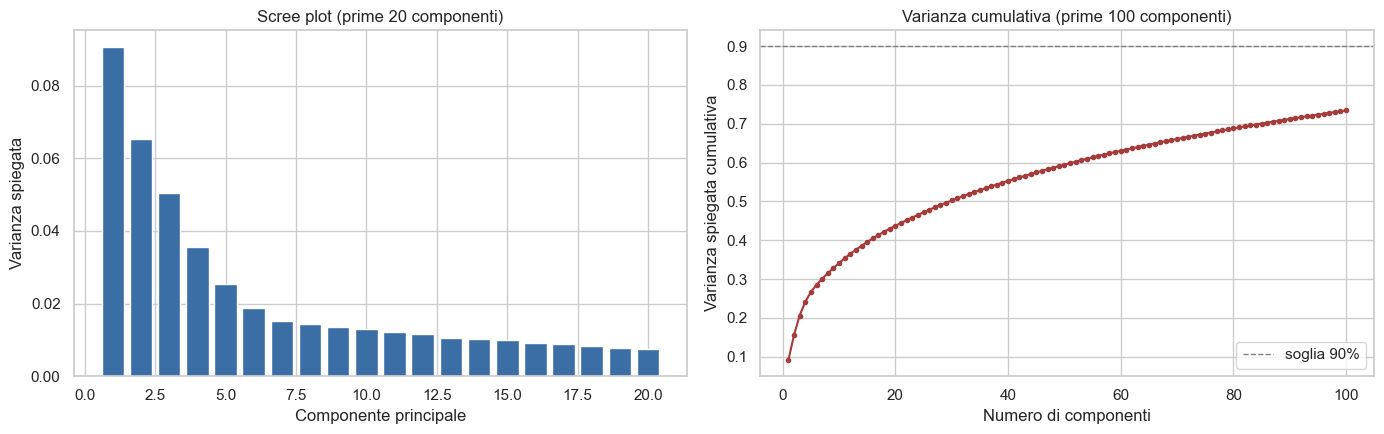

Varianza spiegata dalle prime 2 componenti:   15.6%
Varianza spiegata dalle prime 100 componenti: 73.4%
Componenti necessarie per il 90% della varianza: 237 su 1000


In [6]:
pca_full = PCA(n_components=100, random_state=RANDOM_STATE)
pca_full.fit(X)

# numero di componenti necessarie per il 90% di varianza (soglia vista a lezione)
pca_90 = PCA(n_components=0.90, random_state=RANDOM_STATE).fit(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(range(1, 21), pca_full.explained_variance_ratio_[:20], color='#3b6ea5')
axes[0].set_xlabel('Componente principale')
axes[0].set_ylabel('Varianza spiegata')
axes[0].set_title('Scree plot (prime 20 componenti)')

cum = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, len(cum) + 1), cum, marker='.', color='#a53b3b')
axes[1].axhline(0.9, ls='--', c='gray', lw=1, label='soglia 90%')
axes[1].set_xlabel('Numero di componenti')
axes[1].set_ylabel('Varianza spiegata cumulativa')
axes[1].set_title('Varianza cumulativa (prime 100 componenti)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/pca_varianza.png', bbox_inches='tight')
plt.show()

print(f'Varianza spiegata dalle prime 2 componenti:   {cum[1]:.1%}')
print(f'Varianza spiegata dalle prime 100 componenti: {cum[-1]:.1%}')
print(f'Componenti necessarie per il 90% della varianza: {pca_90.n_components_} su {X.shape[1]}')

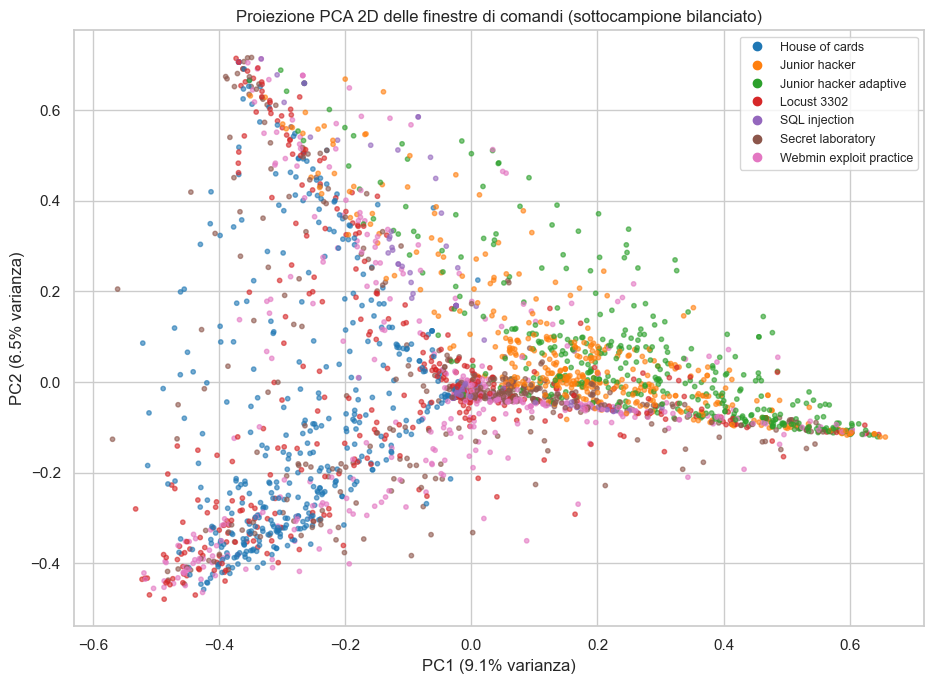

In [7]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(X)

palette = sns.color_palette('tab10', n_colors=len(class_names))
colori_classe = {cl: palette[i] for i, cl in enumerate(class_names)}

# per la visualizzazione si usa un sottocampione bilanciato (max 400 punti per
# classe, disegnati in ordine casuale), altrimenti la classe maggioritaria
# coprirebbe completamente le altre
rng = np.random.RandomState(RANDOM_STATE)
sel = np.concatenate([rng.choice(np.where(y == cl)[0],
                                 size=min(400, (y == cl).sum()), replace=False)
                      for cl in class_names])
rng.shuffle(sel)

plt.figure(figsize=(9.5, 7))
plt.scatter(X_pca2[sel, 0], X_pca2[sel, 1], s=10, alpha=0.6,
            color=[colori_classe[c] for c in y[sel]])
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.1%} varianza)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.1%} varianza)')
plt.title('Proiezione PCA 2D delle finestre di comandi (sottocampione bilanciato)')
legenda = [plt.Line2D([0], [0], marker='o', ls='', color=colori_classe[c], label=c)
           for c in class_names]
plt.legend(handles=legenda, fontsize=9)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/analisi_pca.png', bbox_inches='tight')
plt.show()

**Osservazioni.** La varianza è distribuita su molte componenti, comportamento tipico delle rappresentazioni TF-IDF sparse (ogni documento usa pochi termini del vocabolario): le prime due componenti catturano circa il 16% dell'informazione e ne servono un centinaio per superare il 70%. Nonostante ciò, già nella proiezione 2D emergono **regioni chiaramente associate alle classi**: *Junior hacker adaptive* si addensa a destra in alto, *House of cards* a sinistra, *Locust 3302* lungo il braccio inferiore; le due varianti *Junior hacker* si sovrappongono parzialmente, anticipando la confusione che si osserverà nei classificatori. La struttura è promettente e giustifica l'uso delle 1000 feature TF-IDF complete nei modelli.

## 4. Suddivisione train / validation / test

Poiché le finestre di contesto di una stessa sessione condividono comandi, uno split casuale sui singoli esempi collocherebbe finestre sovrapposte sia in training sia in test, gonfiando artificiosamente le metriche (*leakage*). Lo split viene quindi fatto **a livello di sessione**: tutte le finestre di una sessione finiscono nella stessa partizione. Le sessioni sono suddivise in modo stratificato per scenario in:
* **~70% training** — addestramento dei modelli;
* **~15% validation** — scelta degli iperparametri;
* **~15% test** — valutazione finale, usata una sola volta.

La stessa suddivisione (`random_state=42`) è usata per **tutti** gli esperimenti.

In [8]:
sessioni = df.groupby('session')['scenario'].first().reset_index()
sess_train, sess_temp = train_test_split(sessioni, test_size=0.30,
                                         stratify=sessioni['scenario'],
                                         random_state=RANDOM_STATE)
sess_val, sess_test = train_test_split(sess_temp, test_size=0.50,
                                       stratify=sess_temp['scenario'],
                                       random_state=RANDOM_STATE)

maschere = {nome: df['session'].isin(s['session']).values
            for nome, s in [('train', sess_train), ('validation', sess_val), ('test', sess_test)]}
X_train, y_train = X[maschere['train']], y[maschere['train']]
X_val,   y_val   = X[maschere['validation']], y[maschere['validation']]
X_test,  y_test  = X[maschere['test']], y[maschere['test']]

for nome, chiave, yp in [('Training', 'train', y_train),
                         ('Validation', 'validation', y_val),
                         ('Test', 'test', y_test)]:
    print(f'{nome:<11}: {len(yp):>6} finestre ({len(yp)/len(y):.0%}), '
          f'{df[maschere[chiave]].session.nunique():>3} sessioni')

Training   :  14861 finestre (70%), 186 sessioni
Validation :   3428 finestre (16%),  40 sessioni
Test       :   2800 finestre (13%),  41 sessioni


## 5. Task 2 — Tre algoritmi di classificazione

Vengono confrontati tre algoritmi *shallow* affrontati nel corso:

1. **Logistic Regression** — modello lineare probabilistico basato sulla sigmoide; nel caso multi-classe scikit-learn adotta l'estensione softmax/One-vs-Rest vista a lezione. Baseline classica per dati testuali TF-IDF, con coefficienti interpretabili;
2. **Random Forest** — ensemble di alberi di decisione con *bagging* e selezione casuale delle feature, aggregato per voto di maggioranza; robusto e non lineare;
3. **SVM lineare** — la SVM a **kernel lineare** vista a lezione, che massimizza il margine di separazione tra le classi. Si usa l'implementazione `LinearSVC`, equivalente a `SVC(kernel='linear')` ma molto più scalabile sui ~15.000 esempi di training; poiché `LinearSVC` non espone `predict_proba`, viene avvolta in `CalibratedClassifierCV`, che calibra le probabilità necessarie al calcolo della ROC AUC.

**Iperparametri.** Per i modelli lineari si esplora il parametro di regolarizzazione **C** (il *costo* discusso a lezione per le SVM: C alto → margine stretto, rischio di overfitting; C basso → margine ampio), per la Random Forest il numero di alberi `n_estimators`; per tutti si valuta anche la pesatura `class_weight='balanced'`, che compensa lo sbilanciamento delle classi. La selezione avviene con un ciclo che massimizza la **F1-macro sul validation set**: rispetto alla cross-validation, un validation set fisso ha costo computazionale molto minore e, con ~3.400 esempi, fornisce una stima sufficientemente stabile.

In [9]:
def scegli_modello(nome, candidati):
    """Addestra i candidati sul training set e sceglie quello con F1-macro migliore sul validation set."""
    migliore, migliore_f1, migliore_desc = None, -1, None
    for desc, modello in candidati:
        modello.fit(X_train, y_train)
        f1 = f1_score(y_val, modello.predict(X_val), average='macro')
        print(f'  {nome} [{desc}] -> F1-macro validation = {f1:.4f}')
        if f1 > migliore_f1:
            migliore, migliore_f1, migliore_desc = modello, f1, desc
    print(f'  >> scelto {nome} [{migliore_desc}]\n')
    return migliore

print('Selezione degli iperparametri sul validation set:')
log_reg = scegli_modello('Logistic Regression', [
    (f'C={c}, peso={w}', LogisticRegression(C=c, max_iter=3000, class_weight=w,
                                            random_state=RANDOM_STATE))
    for c in (1, 10) for w in (None, 'balanced')])

random_forest = scegli_modello('Random Forest', [
    (f'n_estimators={n}, peso={w}', RandomForestClassifier(n_estimators=n,
                                                           class_weight=w,
                                                           n_jobs=4,
                                                           random_state=RANDOM_STATE))
    for n in (100, 200) for w in (None, 'balanced')])

svm_lineare = scegli_modello('SVM lineare', [
    (f'C={c}, peso={w}', CalibratedClassifierCV(
        LinearSVC(C=c, class_weight=w, max_iter=5000,
                  random_state=RANDOM_STATE), cv=3))
    for c in (0.1, 1) for w in (None, 'balanced')])

modelli = {
    'Logistic Regression': log_reg,
    'Random Forest': random_forest,
    'SVM lineare': svm_lineare,
}

Selezione degli iperparametri sul validation set:


  Logistic Regression [C=1, peso=None] -> F1-macro validation = 0.7024


  Logistic Regression [C=1, peso=balanced] -> F1-macro validation = 0.6528


  Logistic Regression [C=10, peso=None] -> F1-macro validation = 0.7062


  Logistic Regression [C=10, peso=balanced] -> F1-macro validation = 0.6540
  >> scelto Logistic Regression [C=10, peso=None]



...

  Random Forest [n_estimators=200, peso=balanced] -> F1-macro validation = 0.6858
  >> scelto Random Forest [n_estimators=100, peso=None]



  SVM lineare [C=0.1, peso=None] -> F1-macro validation = 0.6923


  SVM lineare [C=0.1, peso=balanced] -> F1-macro validation = 0.6905


  SVM lineare [C=1, peso=None] -> F1-macro validation = 0.7029


  SVM lineare [C=1, peso=balanced] -> F1-macro validation = 0.7009
  >> scelto SVM lineare [C=1, peso=None]



## 6. Task 3 — Metriche di valutazione sul test set

Per ogni modello si calcolano sul **test set**: **Accuratezza (Accuracy)**, **Precisione (Precision)** = TP/(TP+FP), **Recall (Sensitivity)** = TP/(TP+FN) e la loro media armonica **F-Measure (F1-Score)**, oltre alla **ROC AUC**. Trattandosi di un problema multi-classe con classi sbilanciate — caso in cui, come visto a lezione, l'accuratezza da sola è fuorviante:
* Precision/Recall/F1 usano la **media macro** (calcolate per ciascuna classe e poi mediate, così ogni classe pesa allo stesso modo indipendentemente dal supporto);
* la ROC AUC è calcolata in modalità **One-vs-Rest** (l'estensione multi-classe della curva ROC binaria vista a lezione) con media macro, a partire dalle probabilità predette; nel `classification_report` sono riportate anche le medie *weighted*.

In [10]:
risultati = {}
for nome, modello in modelli.items():
    y_pred = modello.predict(X_test)
    y_proba = modello.predict_proba(X_test)
    risultati[nome] = {
        'y_pred': y_pred,
        'y_proba': y_proba,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall':    recall_score(y_test, y_pred, average='macro', zero_division=0),
        'F-measure': f1_score(y_test, y_pred, average='macro', zero_division=0),
        'ROC AUC':   roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro'),
    }

tabella = pd.DataFrame({n: {k: v for k, v in r.items() if k not in ('y_pred', 'y_proba')}
                        for n, r in risultati.items()}).T.round(4)
tabella.to_csv('risultati_metriche.csv')
tabella

,Accuracy,Precision,Recall,F-measure,ROC AUC
Logistic Regression,0.8221,0.7357,0.6820,0.6900,0.9576
Random Forest,0.8329,0.7959,0.6336,0.6817,0.9360
SVM lineare,0.8196,0.8006,0.6282,0.6666,0.9554


In [11]:
for nome, r in risultati.items():
    print(f'==== {nome} ====')
    print(classification_report(y_test, r['y_pred'], zero_division=0))

==== Logistic Regression ====
                         precision    recall  f1-score   support

         House of cards       0.94      0.64      0.76       216
          Junior hacker       0.42      0.71      0.53       106
 Junior hacker adaptive       0.91      0.84      0.87       783
            Locust 3302       0.83      0.92      0.87      1409
          SQL injection       0.64      0.75      0.69        12
      Secret laboratory       0.88      0.50      0.64       189
Webmin exploit practice       0.53      0.42      0.47        85

               accuracy                           0.82      2800
              macro avg       0.74      0.68      0.69      2800
           weighted avg       0.84      0.82      0.82      2800

==== Random Forest ====
                         precision    recall  f1-score   support

         House of cards       0.85      0.55      0.66       216
          Junior hacker       0.52      0.57      0.54       106
 Junior hacker adaptive       0.

## 7. Task 4 — Matrice di confusione e curva ROC

### 7.1 Matrici di confusione
La matrice di confusione mostra, per ogni classe reale (righe), come si distribuiscono le predizioni (colonne): la diagonale contiene i campioni classificati correttamente.

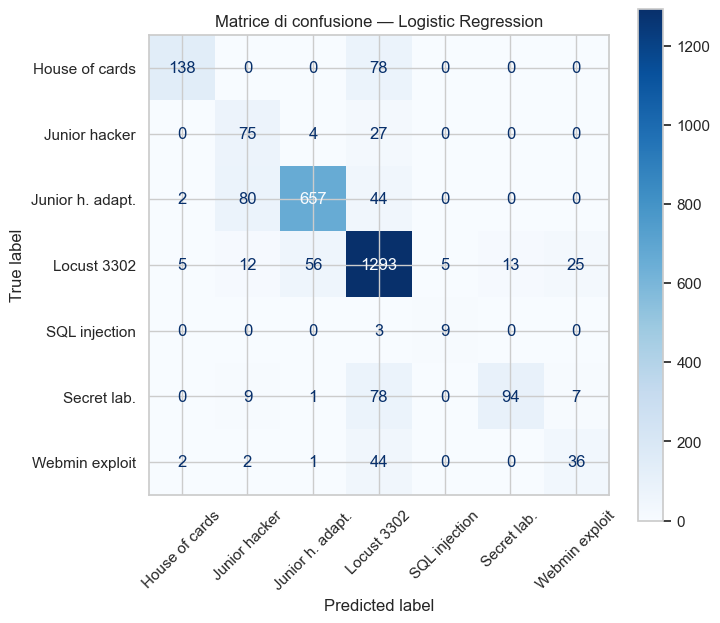

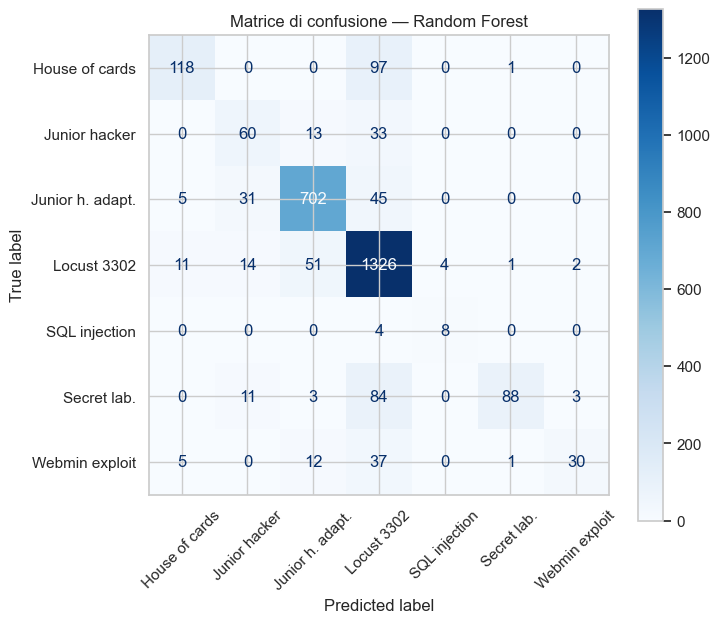

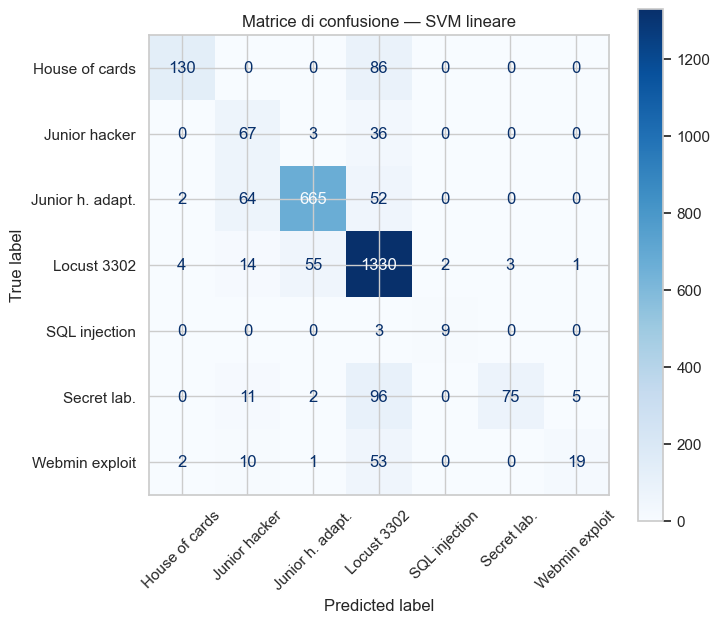

In [12]:
abbrev = {'House of cards': 'House of cards', 'Junior hacker': 'Junior hacker',
          'Junior hacker adaptive': 'Junior h. adapt.', 'Locust 3302': 'Locust 3302',
          'SQL injection': 'SQL injection', 'Secret laboratory': 'Secret lab.',
          'Webmin exploit practice': 'Webmin exploit'}

for nome, r in risultati.items():
    cm = confusion_matrix(y_test, r['y_pred'], labels=class_names)
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    disp = ConfusionMatrixDisplay(cm, display_labels=[abbrev[c] for c in class_names])
    disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45, values_format='d')
    ax.set_title(f'Matrice di confusione — {nome}')
    plt.tight_layout()
    slug = nome.lower().replace(' ', '_')
    plt.savefig(f'{IMG_DIR}/matrice_confusione_{slug}.png', bbox_inches='tight')
    plt.show()

### 7.2 Curve ROC (One-vs-Rest)

In ambito multi-classe la curva ROC (True Positive Rate in funzione del False Positive Rate) viene tracciata **per ogni classe contro tutte le altre** (One-vs-Rest), usando le probabilità predette. Oltre alle curve per classe si riporta la curva **micro-average** (aggregazione di tutte le predizioni, come mostrato a lezione); nel titolo compare la **media macro** delle AUC, preferita nella tabella riassuntiva perché con classi sbilanciate la micro-average è dominata dalla classe maggioritaria. Un'area sotto la curva (AUC) vicina a 1 indica un classificatore che distingue molto bene la classe dalle altre; la diagonale rappresenta il classificatore casuale (AUC = 0.5).

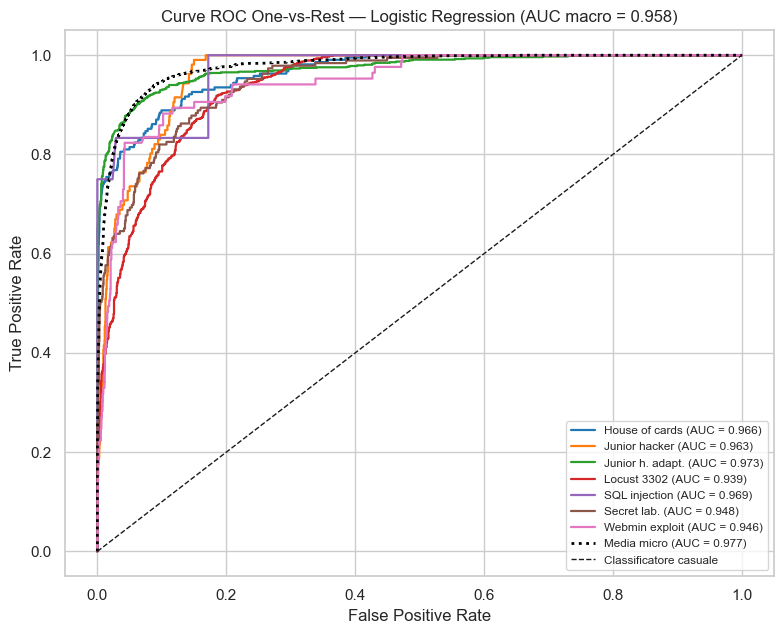

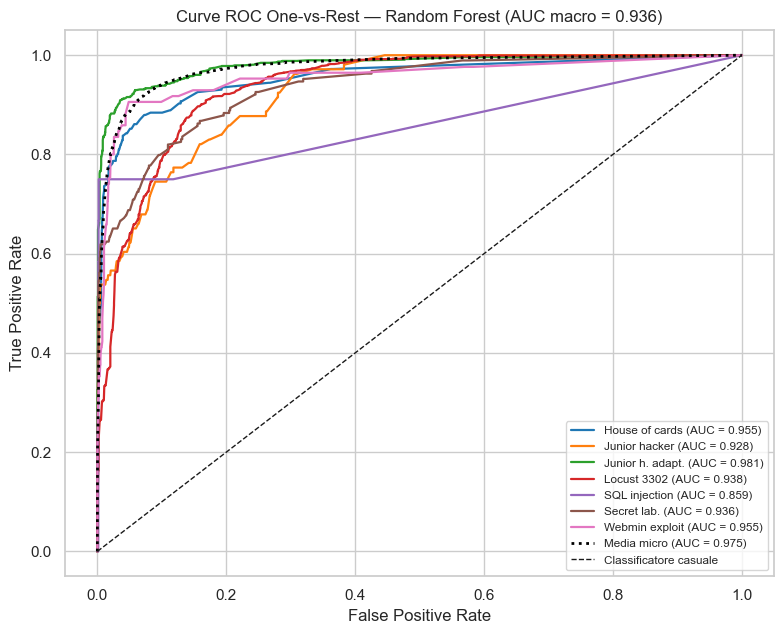

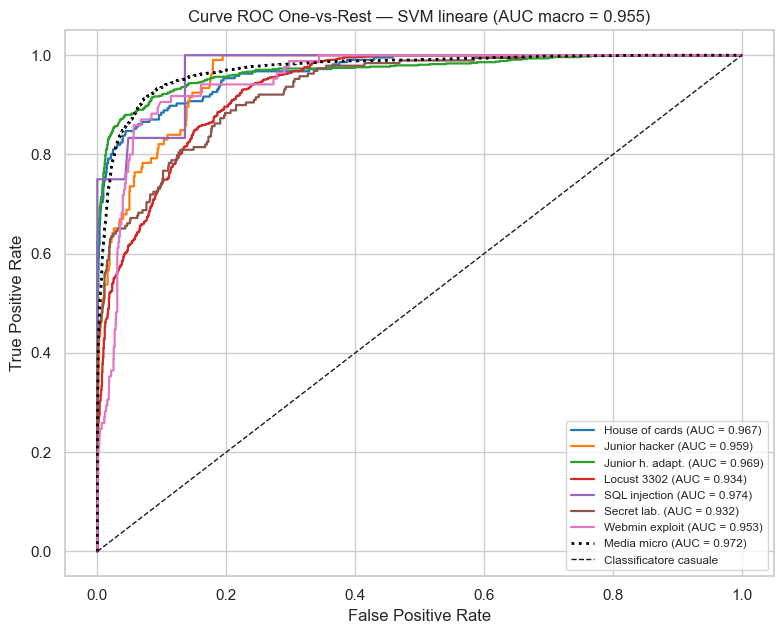

In [13]:
y_test_bin = label_binarize(y_test, classes=class_names)

for nome, r in risultati.items():
    proba = r['y_proba']
    fig, ax = plt.subplots(figsize=(8, 6.5))
    for i, cl in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=1.6, color=palette[i],
                label=f'{abbrev[cl]} (AUC = {roc_auc:.3f})')
    fpr_mi, tpr_mi, _ = roc_curve(y_test_bin.ravel(), proba.ravel())
    ax.plot(fpr_mi, tpr_mi, color='black', lw=2, ls=':',
            label=f'Media micro (AUC = {auc(fpr_mi, tpr_mi):.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Classificatore casuale')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    macro = risultati[nome]['ROC AUC']
    ax.set_title(f'Curve ROC One-vs-Rest — {nome} (AUC macro = {macro:.3f})')
    ax.legend(fontsize=8.5, loc='lower right')
    plt.tight_layout()
    slug = nome.lower().replace(' ', '_')
    plt.savefig(f'{IMG_DIR}/curva_roc_{slug}.png', bbox_inches='tight')
    plt.show()

## 8. Task 5 (opzione b) — Spiegabilità con SHAP

Come quinto task si adotta l'approccio di **spiegabilità post-hoc SHAP** (SHapley Additive exPlanations). SHAP appartiene agli *additive feature attribution methods*: attribuisce a ogni feature un valore di importanza per ogni singola predizione basandosi sui **valori di Shapley** della teoria dei giochi cooperativi, gli unici a soddisfare le proprietà assiomatiche di **efficienza** (i contributi sommati al valore base E[f(x)] ricostruiscono la predizione), **simmetria**, **nullità** e **additività**. Rispetto a LIME — l'altro approccio *model-agnostic* visto a lezione, più economico ma privo di garanzie teoriche e instabile — SHAP è in generale più costoso, **tranne che per i modelli ad albero**, per i quali l'algoritmo **TreeSHAP** (`shap.TreeExplainer`, *model-specific*) calcola i valori in tempo polinomiale: per questo lo si applica alla **Random Forest**.

SHAP consente sia la spiegazione **globale** (importanza media delle feature sull'intero dataset) sia quella **locale** (contributi delle feature a una singola predizione): di seguito vengono mostrate entrambe. Gli alberi della foresta addestrata su dati testuali sono molto profondi e il calcolo esatto sarebbe comunque proibitivo: si usa quindi la variante **approssimata** (`approximate=True`, algoritmo di Saabas), che preserva l'ordinamento qualitativo delle feature, su un **sottocampione casuale di 400 finestre del test set**.

In [14]:
rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(len(X_test), size=400, replace=False)
X_shap = pd.DataFrame(X_test[idx], columns=feature_names)

explainer = shap.TreeExplainer(random_forest)
shap_values = explainer.shap_values(X_shap.values, check_additivity=False,
                                    approximate=True)

# a seconda della versione di SHAP l'output e' una lista per classe
# oppure un array (campioni, feature, classi): si uniforma a lista per classe
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

rf_classi = list(random_forest.classes_)
print(f'Valori SHAP calcolati: {len(shap_values)} classi, {X_shap.shape} (campioni x feature)')

Valori SHAP calcolati: 7 classi, (400, 1000) (campioni x feature)


/tmp/ipykernel_1625875/2747373415.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, plot_type='bar',


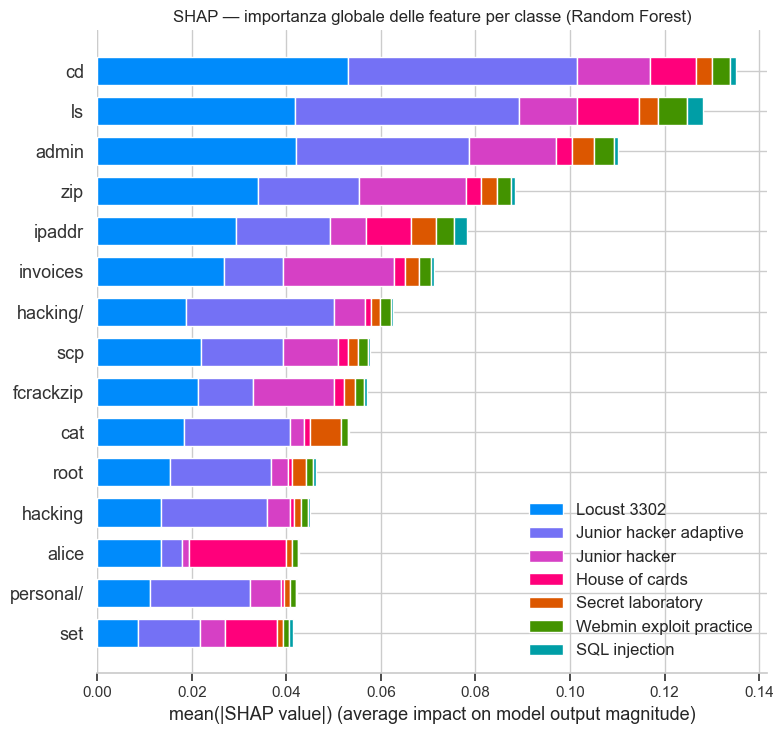

In [15]:
plt.close('all')  # evita sovrapposizioni con figure precedenti
shap.summary_plot(shap_values, X_shap, plot_type='bar',
                  class_names=rf_classi, max_display=15, show=False)
plt.title('SHAP — importanza globale delle feature per classe (Random Forest)')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/shap_summary_bar.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_1625875/3800015364.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[i_focus], X_shap, max_display=15, show=False)


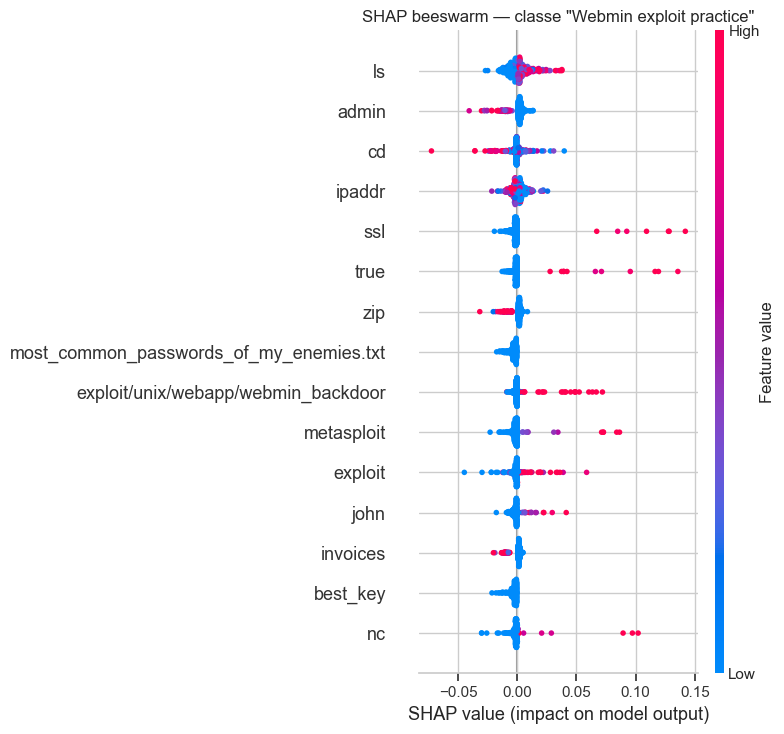

In [16]:
# beeswarm plot per la classe 'Webmin exploit practice': mostra come i valori
# delle feature (colore) spingono la predizione verso/contro la classe
plt.close('all')
classe_focus = 'Webmin exploit practice'
i_focus = rf_classi.index(classe_focus)
shap.summary_plot(shap_values[i_focus], X_shap, max_display=15, show=False)
plt.title(f'SHAP beeswarm — classe "{classe_focus}"')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/shap_beeswarm_webmin.png', bbox_inches='tight')
plt.show()

### 8.1 Spiegazione locale di una singola predizione (waterfall plot)

Il **waterfall plot** — il grafico usato a lezione per la spiegabilità locale — mostra come si passa dal **valore base E[f(x)]** (la probabilità media della classe sul training) alla probabilità predetta per un singolo esempio, sommando i contributi SHAP delle feature (proprietà di efficienza). Si sceglie una finestra del test set classificata correttamente come *Webmin exploit practice*.

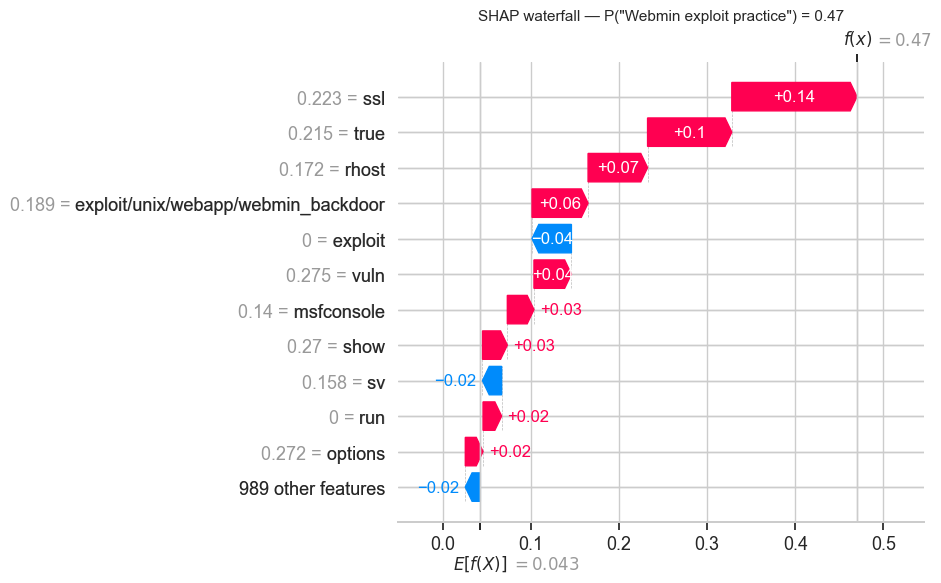

Finestra di comandi spiegata (estratto):
  nmap -sv --script=vuln  IPADDR  mfs mfsconsole msfconsole use exploit/unix/webapp/webmin_backdoor  show options set rhost  IPADDR  set lhost  IPADDR  set ssl true show options use exploit/


In [17]:
plt.close('all')
y_shap = y_test[idx]                      # etichette vere del sottocampione
pred_shap = random_forest.predict(X_shap.values)

# primo esempio del sottocampione predetto correttamente come classe_focus
i_locale = int(np.where((y_shap == classe_focus) & (pred_shap == classe_focus))[0][0])
proba_locale = random_forest.predict_proba(X_shap.values[i_locale:i_locale + 1])[0, i_focus]

spiegazione = shap.Explanation(
    values=shap_values[i_focus][i_locale],
    base_values=float(np.ravel(explainer.expected_value)[i_focus]),
    data=X_shap.values[i_locale],
    feature_names=list(feature_names))
shap.plots.waterfall(spiegazione, max_display=12, show=False)
plt.gcf().set_size_inches(9.5, 6)
plt.title(f'SHAP waterfall — P("{classe_focus}") = {proba_locale:.2f}', fontsize=11)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/shap_waterfall_locale.png', bbox_inches='tight')
plt.show()

comandi_finestra = df.loc[maschere['test']].iloc[idx[i_locale]]['doc']
print('Finestra di comandi spiegata (estratto):')
print(' ', comandi_finestra[-250:])

**Lettura dei risultati SHAP.** Il grafico a barre mostra le feature (termini TF-IDF) mediamente più influenti per ciascuna classe; il *beeswarm* dettaglia una classe: ogni punto è una finestra del test set, il colore indica il valore TF-IDF del termine (rosso = alto) e la posizione orizzontale l'effetto sulla predizione. Il *waterfall* rende conto della singola decisione: i termini caratteristici presenti nella finestra spingono la probabilità dal valore base verso la predizione. In tutti e tre i livelli di analisi i termini più importanti sono i **nomi degli strumenti e dei bersagli caratteristici di ogni esercitazione** (es. `webmin` per lo scenario *Webmin exploit practice*, i comandi Metasploit per gli scenari offensivi): il modello ha quindi imparato pattern coerenti con la semantica del problema, non artefatti dei dati.

## 9. Conclusioni

* Il singolo comando shell è spesso **intrinsecamente ambiguo** (tetto teorico di accuracy ≈ 0.80): la rappresentazione a **finestra di contesto** (comando + 10 precedenti) con TF-IDF si è rivelata la scelta progettuale decisiva.
* Lo split **per sessione** garantisce una stima onesta della generalizzazione: il modello viene valutato su sessioni di partecipanti mai visti in training.
* L'analisi **PCA** ha mostrato che la varianza è distribuita su molte componenti, ma già in 2D emergono addensamenti coerenti con le classi.
* I tre classificatori raggiungono buone prestazioni; le matrici di confusione evidenziano che gli errori si concentrano sulle classi con pochissime sessioni (*SQL injection*) e sulle coppie di scenari affini (*Junior hacker* / *Junior hacker adaptive*, due varianti della stessa esercitazione).
* Le curve **ROC One-vs-Rest** mostrano AUC elevate per quasi tutte le classi.
* L'analisi **SHAP** rende interpretabile il modello: le feature decisive sono i termini specifici degli strumenti usati in ciascuna esercitazione.

**Limiti e sviluppi futuri:** le classi con poche sessioni rendono instabili le metriche macro sul test set; si potrebbero raccogliere più dati o unire le due varianti *Junior hacker*. Un naturale sviluppo è un approccio deep (embedding dei token + rete ricorrente o transformer) sugli stessi split per sessione.